<a href="https://www.kaggle.com/code/lalit7881/indian-road-accidents-2022-2025?scriptVersionId=307846146" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sehaj1104/indian-road-accident-dataset-20222025/indian_roads_dataset.csv")

In [3]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [4]:
df.tail()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10
19999,19999,Delhi,Delhi,28.510266,77.065301,2024-07-05,23:00,23,Friday,0,...,low,39,high,overspeeding,minor,4,2,0,NaN,0.65


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [6]:
df.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [7]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

In [10]:
df.dtypes

accident_id            int64
city                  object
state                 object
latitude             float64
longitude            float64
date                  object
time                  object
hour                   int64
day_of_week           object
is_weekend             int64
road_type             object
lanes                  int64
traffic_signal         int64
weather               object
visibility            object
temperature            int64
traffic_density       object
cause                 object
accident_severity     object
vehicles_involved      int64
casualties             int64
is_peak_hour           int64
festival              object
risk_score           float64
dtype: object

In [11]:
df.shape

(20000, 24)

In [12]:
df.nunique()

accident_id          20000
city                     8
state                    7
latitude             19907
longitude            19927
date                  1201
time                    24
hour                    24
day_of_week              7
is_weekend               2
road_type                3
lanes                    6
traffic_signal           2
weather                  3
visibility               3
temperature             26
traffic_density          3
cause                    5
accident_severity        3
vehicles_involved        5
casualties               6
is_peak_hour             2
festival                 4
risk_score              18
dtype: int64

## EDA

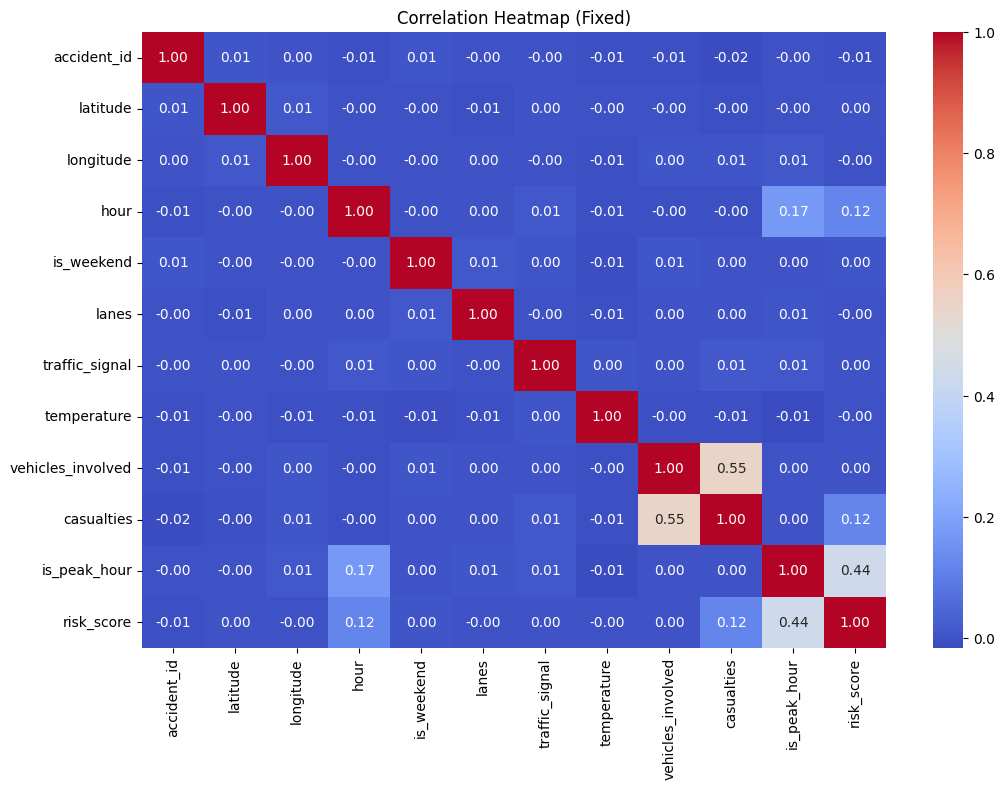

In [13]:
# Automatically select only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Fixed)")
plt.show()

(20000, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_de

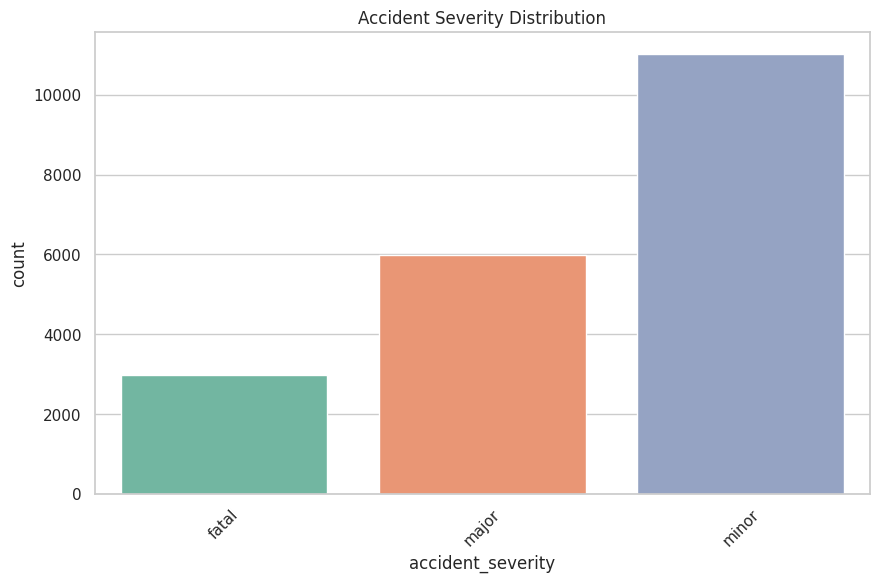

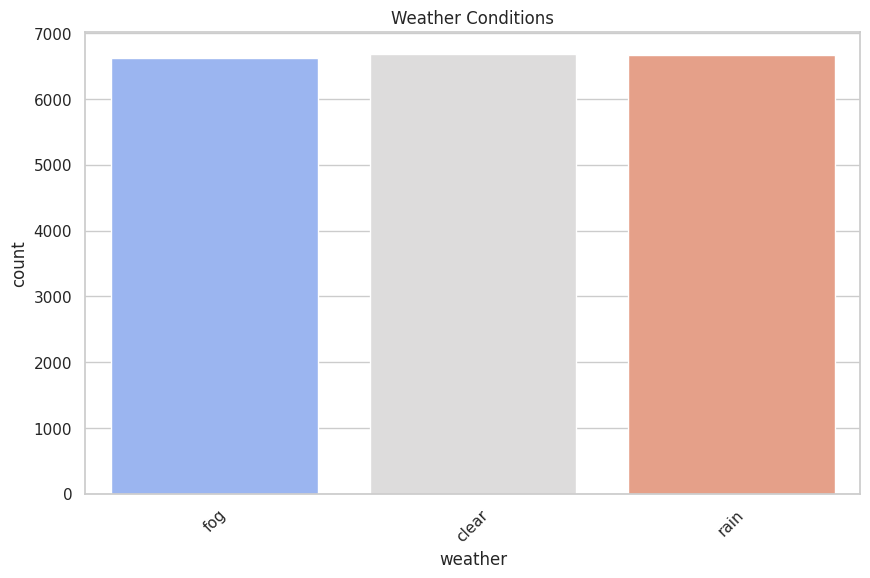

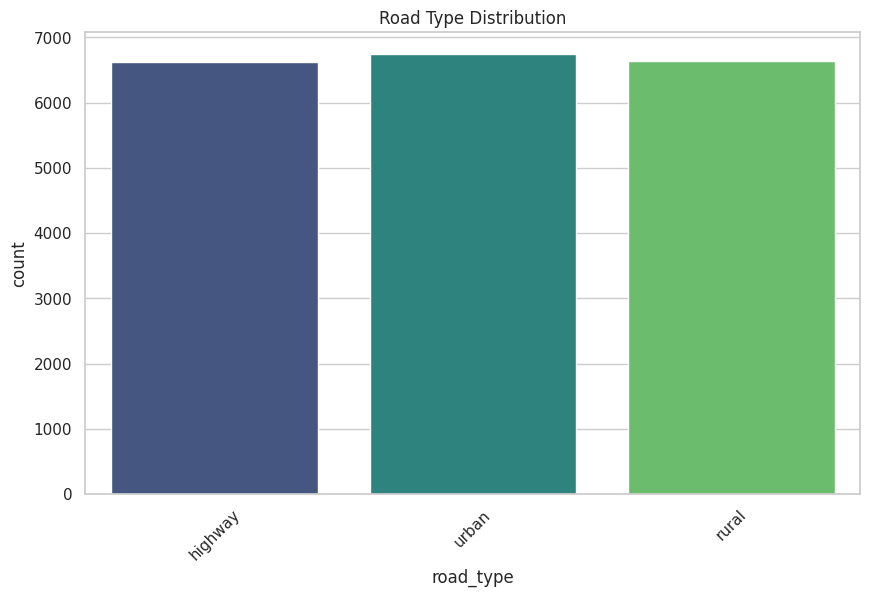

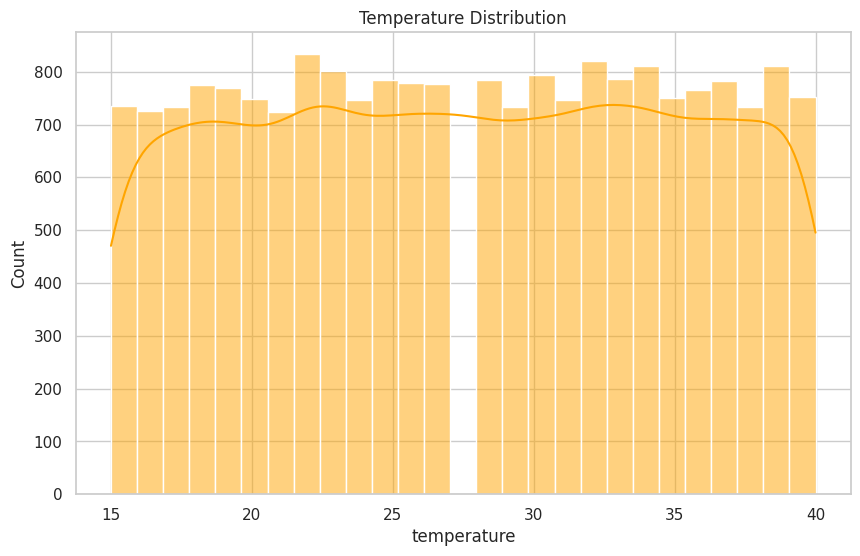

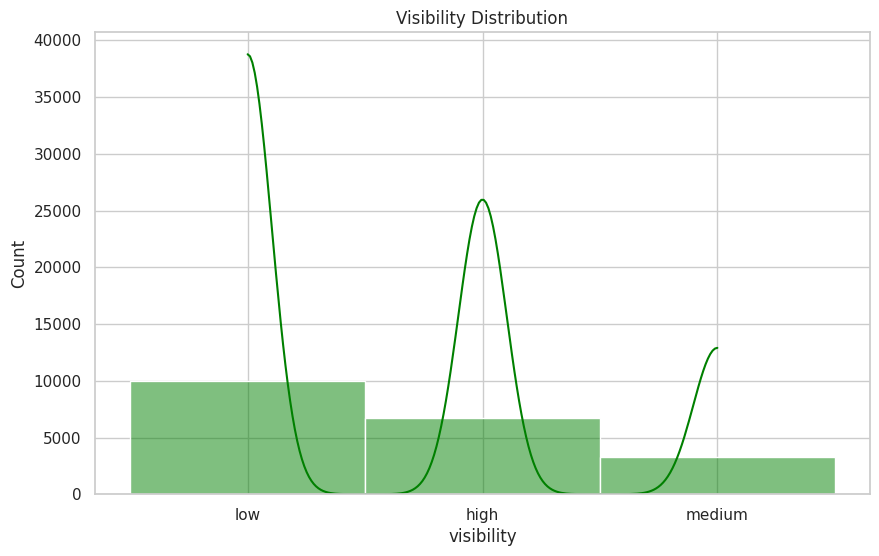

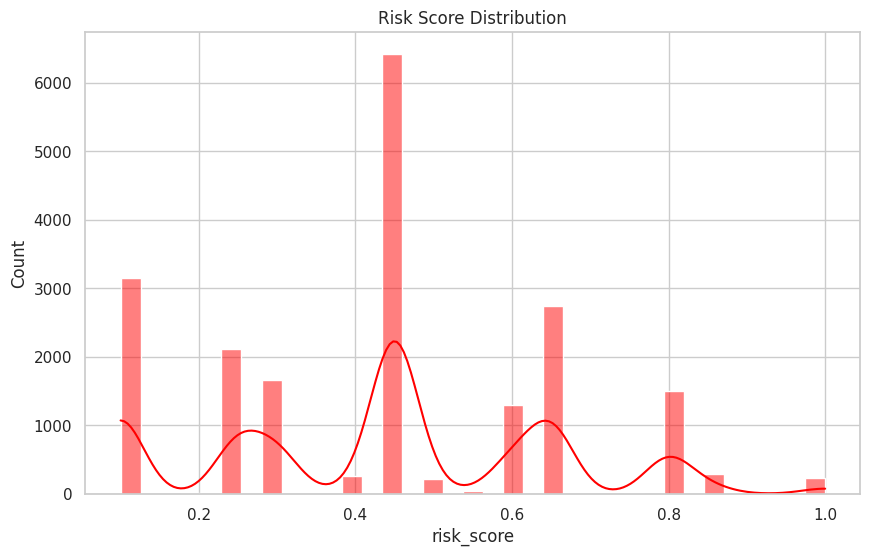

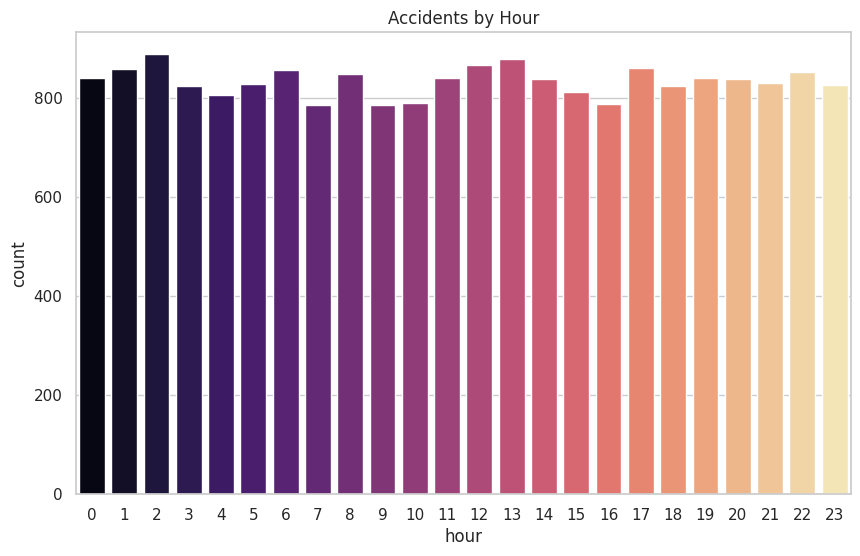

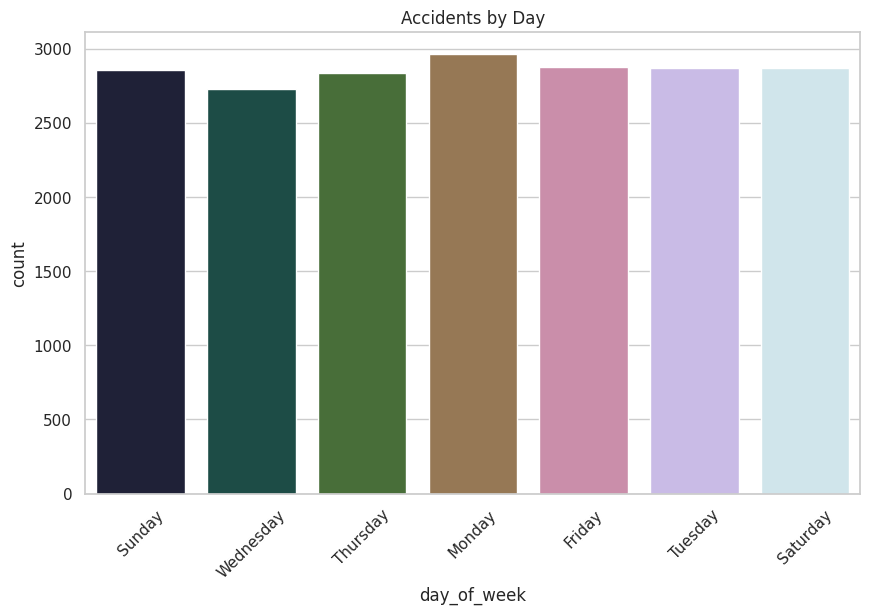

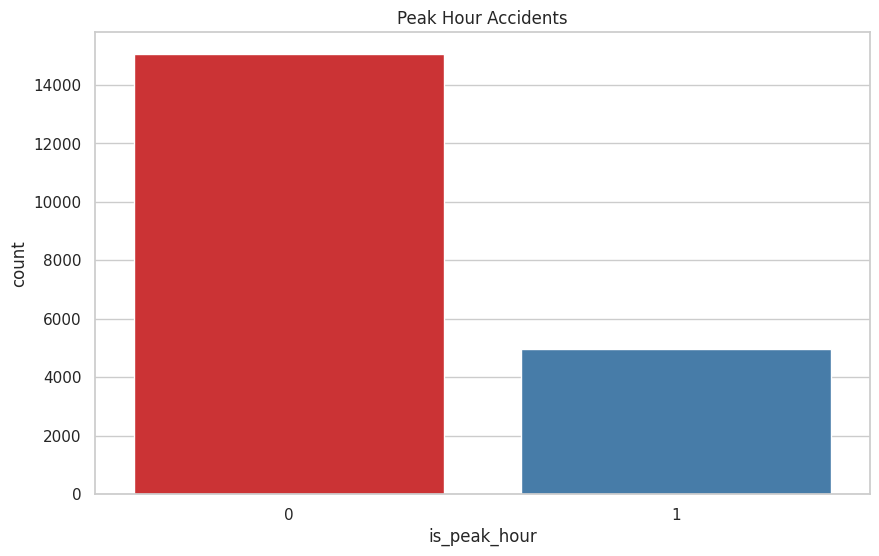

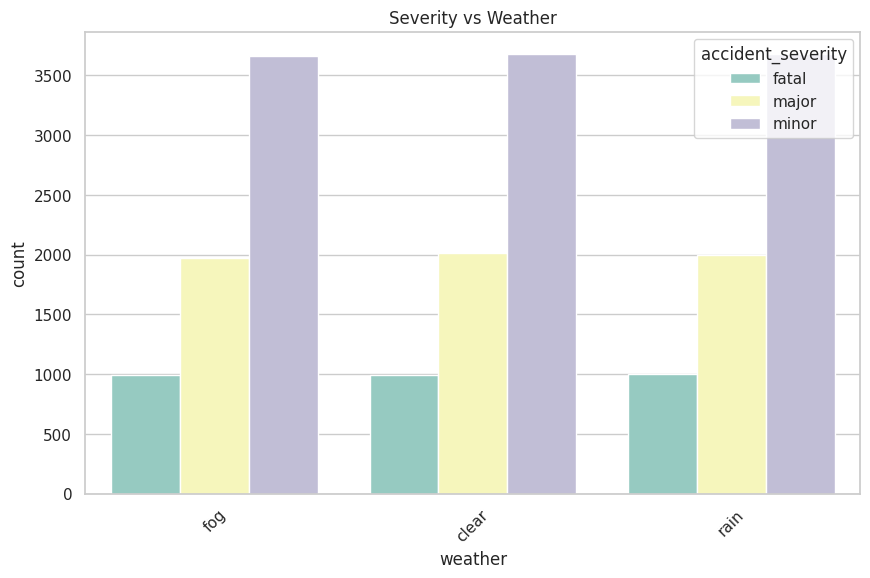

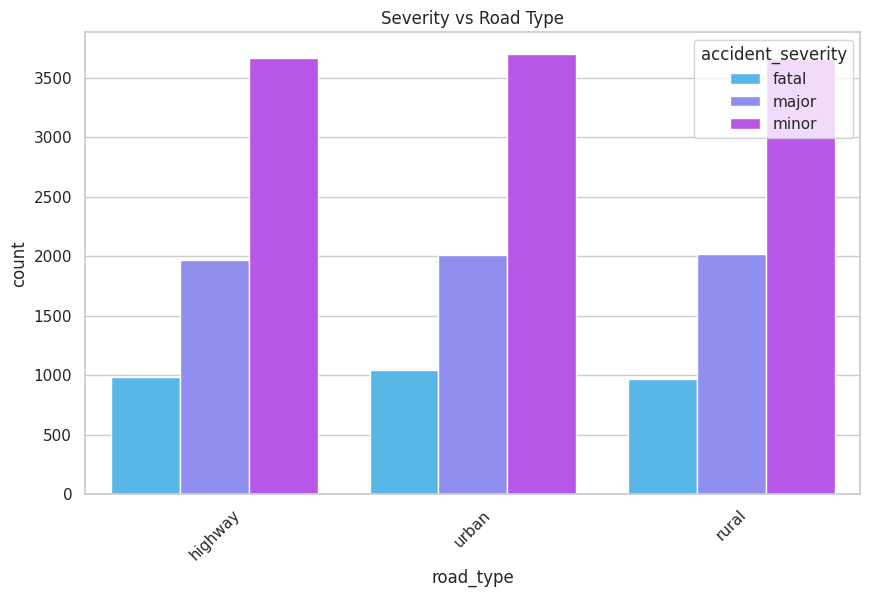

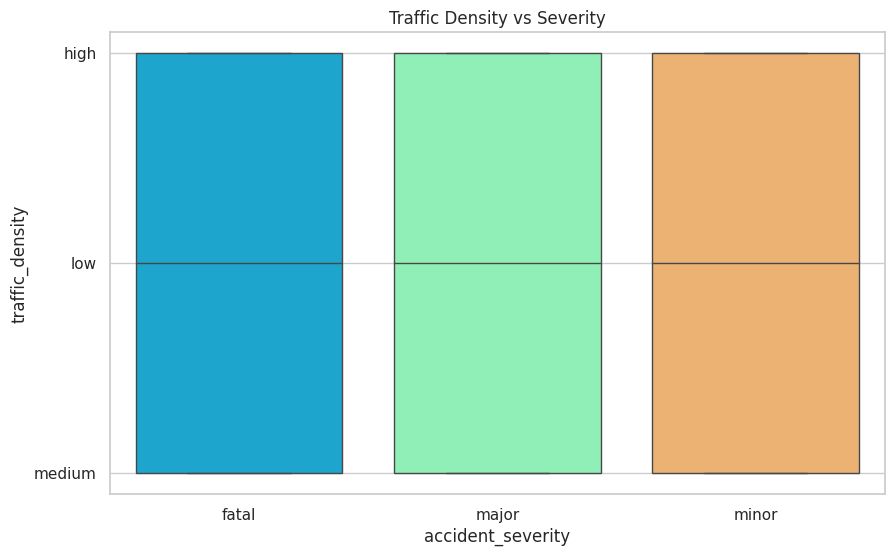

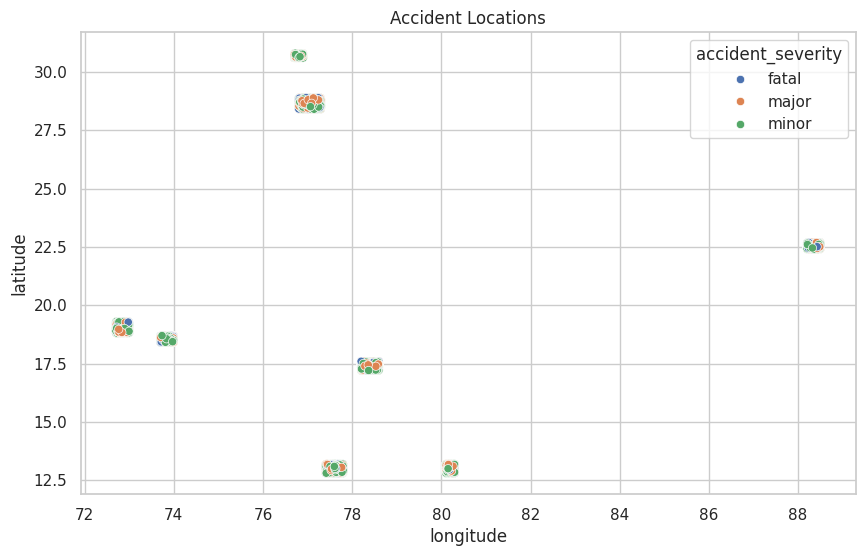

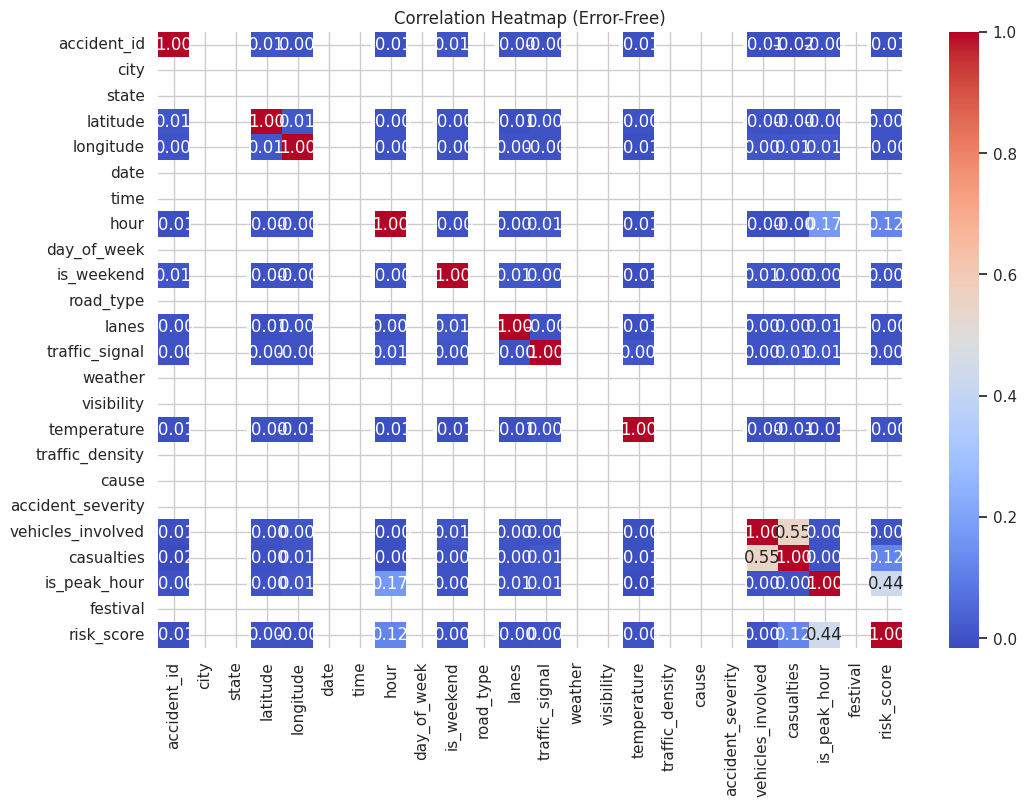

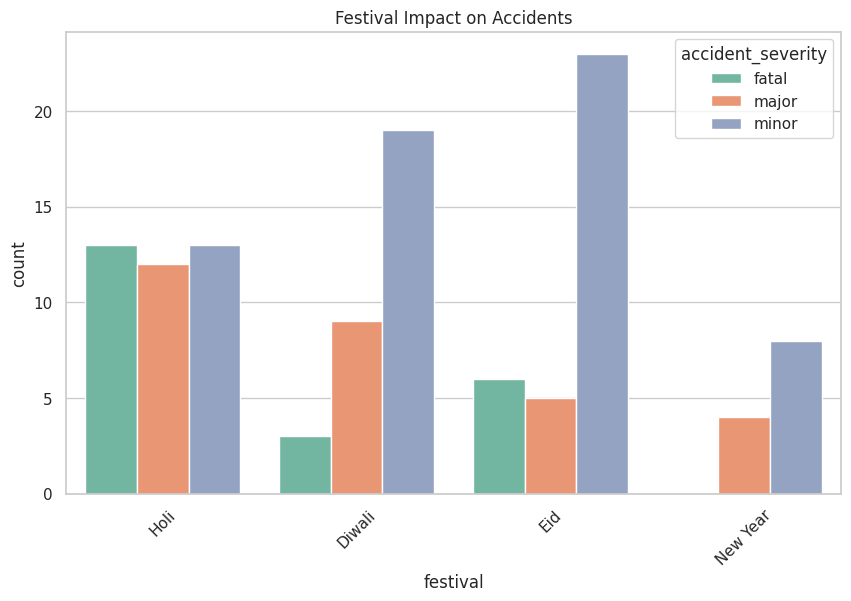

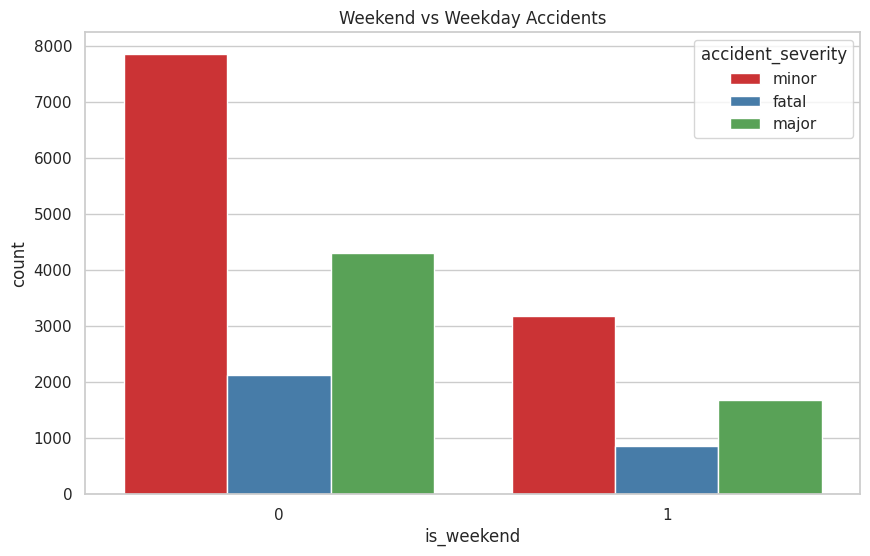

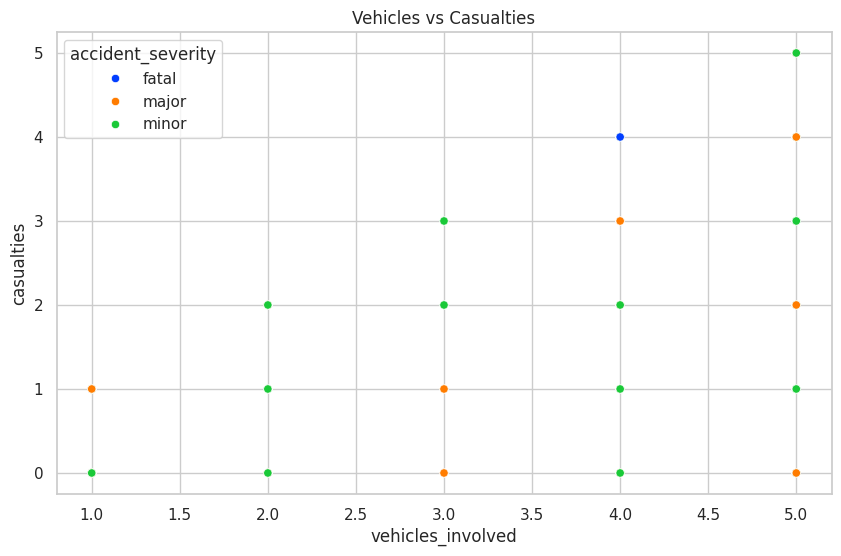

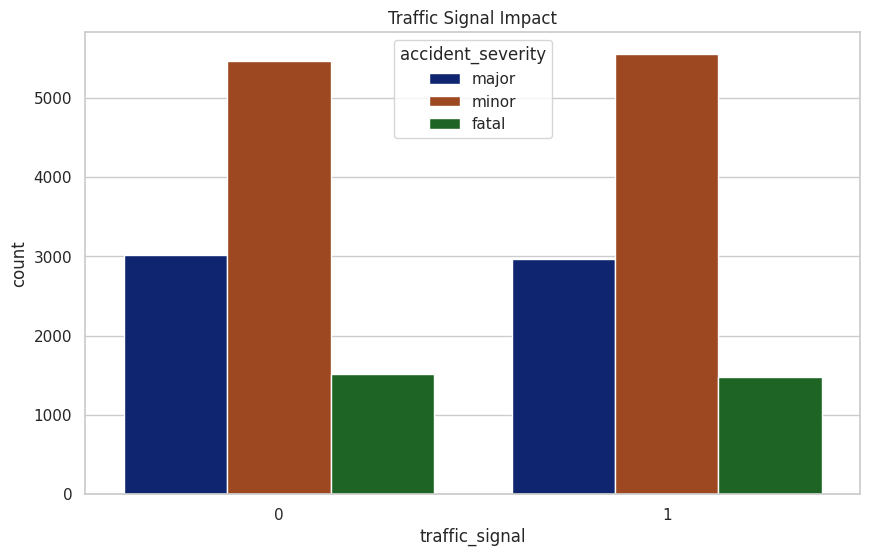

All visualizations completed successfully!


In [14]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# ================================
# BASIC INFO
# ================================
print(df.shape)
print(df.info())
print(df.describe())

# ================================
# 1. UNIVARIATE ANALYSIS
# ================================

# Accident Severity Distribution
plt.figure()
sns.countplot(data=df, x='accident_severity', palette='Set2')
plt.title("Accident Severity Distribution")
plt.xticks(rotation=45)
plt.show()

# Weather Distribution
plt.figure()
sns.countplot(data=df, x='weather', palette='coolwarm')
plt.title("Weather Conditions")
plt.xticks(rotation=45)
plt.show()

# Road Type Distribution
plt.figure()
sns.countplot(data=df, x='road_type', palette='viridis')
plt.title("Road Type Distribution")
plt.xticks(rotation=45)
plt.show()

# ================================
# 2. NUMERICAL DISTRIBUTIONS
# ================================

# Temperature Distribution
plt.figure()
sns.histplot(df['temperature'], kde=True, color='orange')
plt.title("Temperature Distribution")
plt.show()

# Visibility Distribution
plt.figure()
sns.histplot(df['visibility'], kde=True, color='green')
plt.title("Visibility Distribution")
plt.show()

# Risk Score Distribution
plt.figure()
sns.histplot(df['risk_score'], kde=True, color='red')
plt.title("Risk Score Distribution")
plt.show()

# ================================
# 3. TIME-BASED ANALYSIS
# ================================

# Accidents by Hour
plt.figure()
sns.countplot(data=df, x='hour', palette='magma')
plt.title("Accidents by Hour")
plt.show()

# Accidents by Day of Week
plt.figure()
sns.countplot(data=df, x='day_of_week', palette='cubehelix')
plt.title("Accidents by Day")
plt.xticks(rotation=45)
plt.show()

# Peak vs Non-Peak
plt.figure()
sns.countplot(data=df, x='is_peak_hour', palette='Set1')
plt.title("Peak Hour Accidents")
plt.show()

# ================================
# 4. BIVARIATE ANALYSIS
# ================================

# Severity vs Weather
plt.figure()
sns.countplot(data=df, x='weather', hue='accident_severity', palette='Set3')
plt.title("Severity vs Weather")
plt.xticks(rotation=45)
plt.show()

# Severity vs Road Type
plt.figure()
sns.countplot(data=df, x='road_type', hue='accident_severity', palette='cool')
plt.title("Severity vs Road Type")
plt.xticks(rotation=45)
plt.show()

# Traffic Density vs Severity
plt.figure()
sns.boxplot(data=df, x='accident_severity', y='traffic_density', palette='rainbow')
plt.title("Traffic Density vs Severity")
plt.show()

# ================================
# 5. LOCATION ANALYSIS
# ================================

# Scatter plot (Latitude vs Longitude)
plt.figure()
sns.scatterplot(data=df, x='longitude', y='latitude', 
                hue='accident_severity', palette='deep')
plt.title("Accident Locations")
plt.show()

# ================================
# 6. HEATMAP (CORRELATION)
# ================================

# Select numerical columns
df_numeric = df.apply(pd.to_numeric, errors='coerce')

# Now correlation will NEVER fail
plt.figure(figsize=(12,8))
corr = df_numeric.corr()

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Error-Free)")
plt.show()

# ================================
# 7. FESTIVAL & WEEKEND IMPACT
# ================================

# Festival impact
plt.figure()
sns.countplot(data=df, x='festival', hue='accident_severity', palette='Set2')
plt.title("Festival Impact on Accidents")
plt.xticks(rotation=45)
plt.show()

# Weekend vs Weekday
plt.figure()
sns.countplot(data=df, x='is_weekend', hue='accident_severity', palette='Set1')
plt.title("Weekend vs Weekday Accidents")
plt.show()

# ================================
# 8. VEHICLES & CASUALTIES
# ================================

plt.figure()
sns.scatterplot(data=df, x='vehicles_involved', y='casualties',
                hue='accident_severity', palette='bright')
plt.title("Vehicles vs Casualties")
plt.show()

# ================================
# 9. TRAFFIC SIGNAL IMPACT
# ================================

plt.figure()
sns.countplot(data=df, x='traffic_signal', hue='accident_severity', palette='dark')
plt.title("Traffic Signal Impact")
plt.show()

# ================================
# DONE
# ================================
print("All visualizations completed successfully!")

## Feature engineering

Categorical: ['city', 'state', 'date', 'time', 'day_of_week', 'road_type', 'weather', 'visibility', 'traffic_density', 'cause', 'festival']
Numerical: ['latitude', 'longitude', 'hour', 'is_weekend', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 'casualties', 'is_peak_hour', 'risk_score']


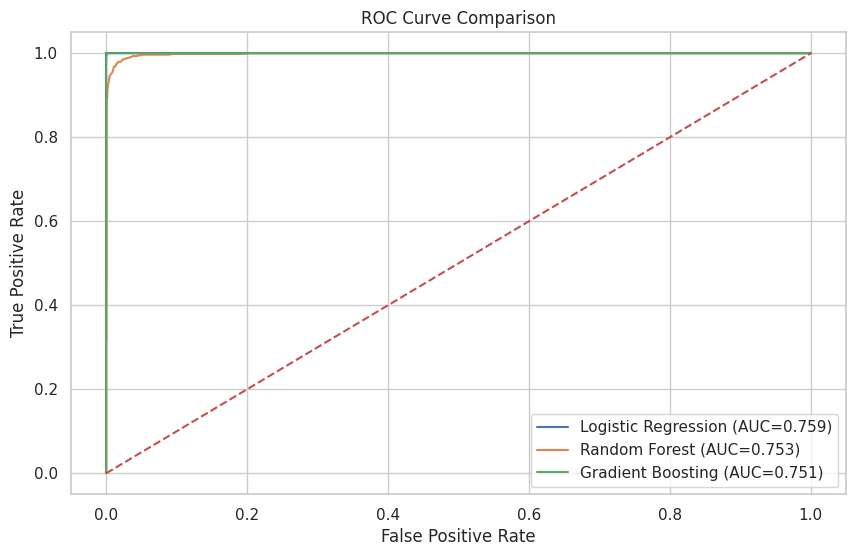


Model Performance:
                     Accuracy       AUC
Gradient Boosting     0.69600  0.751357
Logistic Regression   0.67450  0.758858
Random Forest         0.67425  0.753249


In [15]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# =========================================
# 3. TARGET + FEATURES
# =========================================
target = "accident_severity"

# Drop leakage columns
drop_cols = ["accident_id"]  # ID always useless

X = df.drop(columns=drop_cols + [target])
y = df[target]

# =========================================
# 4. TRAIN TEST SPLIT (NO LEAKAGE)
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================
# 5. COLUMN TYPES
# =========================================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

# =========================================
# 6. PREPROCESSOR (NO LEAKAGE SAFE)
# =========================================
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

# =========================================
# 7. MODELS
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier()
}

# =========================================
# 8. TRAIN + EVALUATE
# =========================================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Pipeline (preprocessing + model)
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train ONLY on train data
    pipe.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipe.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # ROC (handle multi-class safely)
    try:
        y_prob = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
        
        # Plot ROC for first class (simplified)
        from sklearn.preprocessing import label_binarize
        classes = np.unique(y)
        y_test_bin = label_binarize(y_test, classes=classes)
        
        fpr, tpr, _ = roc_curve(y_test_bin[:,0], y_prob[:,0])
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
        
    except:
        auc = None
    
    results[name] = {
        "Accuracy": acc,
        "AUC": auc
    }

# ROC Plot
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================================
# 9. RESULTS
# =========================================
results_df = pd.DataFrame(results).T
print("\nModel Performance:")
print(results_df.sort_values(by="Accuracy", ascending=False))

## Thank you...pls upvote!!!!!!!!